# Gold Nanoparticle Reconstruction in `quantEM`

Tutorial by Stephanie Ribet, LBNL (`sribet@lbl.gov`) and Georgios Varnavides (`G.Varnavides@tudelft.nl`), TU Delft

Data collected by Stephanie Ribet, TEAM I, May 2026

Work at the Molecular Foundry was supported by the Office of Science, Office of Basic Energy Sciences, of the U.S. Department of Energy under Contract No. DE-AC02-05CH11231.

## What this notebook does

This tutorial walks through a complete ptychography workflow for a gold nanoparticle dataset in `quantEM`.

By the end of the notebook you will have:

1. Loaded a 4D-STEM dataset and set the microscope calibration values.
2. Checked the diffraction data quality and calibrated the data.
3. Generated simple virtual BF and DF images.
4. Run a direct ptychographic reconstruction and refine key hyperparameters.
5. Run an iterative ptychographic reconstruction with `PtychoLite` using the optimized parameters from direct ptychography.
6. Compared the strengths and limitations of the two approaches.

## 1. Setup and Calibration Inputs

Start by importing the packages we need and setting the compute device. Then define the two microscope parameters that will be used throughout the notebook:

- `probe_semiangle`: the probe convergence semiangle in mrad.
- `energy`: the beam energy in eV.

These values are needed so `quantEM` can convert between detector pixels and physically meaningful reciprocal-space coordinates. This dataset already has the real space calibration loaded thanks to metadata captured by the detector. If you did not know your real space calibration, you would follow a similar workflow to calibrate the dataset.


In [1]:
%pip install -q git+https://github.com/electronmicroscopy/quantem.git@dev

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 24.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import quantem as em

from quantem.core import config
from quantem.core.visualization import show_2d
import matplotlib.pyplot as plt

In [4]:
import os
import gdown

dirpath = "/content/"
filepath_data = dirpath + "gold_ptycho.zip"

if not os.path.exists(filepath_data):
    gdown.download(
        id="1nAoBFENHzyZov1IAxiTbSn2hNQwV6ktz",
        output=filepath_data,
        quiet=False,
    )

Downloading...
From (original): https://drive.google.com/uc?id=1nAoBFENHzyZov1IAxiTbSn2hNQwV6ktz
From (redirected): https://drive.google.com/uc?id=1nAoBFENHzyZov1IAxiTbSn2hNQwV6ktz&confirm=t&uuid=119de6f4-24c2-49f8-b35d-4a784e806018
To: /content/gold_ptycho.zip

  0%|          | 0.00/88.2M [00:00<?, ?B/s]
  1%|          | 1.05M/88.2M [00:00<00:10, 8.53MB/s]
 10%|█         | 8.91M/88.2M [00:00<00:01, 45.8MB/s]
 24%|██▍       | 21.5M/88.2M [00:00<00:00, 78.4MB/s]
 40%|███▉      | 35.1M/88.2M [00:00<00:00, 99.5MB/s]
 55%|█████▍    | 48.2M/88.2M [00:00<00:00, 108MB/s] 
 70%|██████▉   | 61.3M/88.2M [00:00<00:00, 110MB/s]
 86%|████████▌ | 75.5M/88.2M [00:00<00:00, 120MB/s]
100%|██████████| 88.2M/88.2M [00:00<00:00, 102MB/s]


In [5]:
probe_semiangle = 21.9
energy = 300e3

## 2. Load the Dataset

Load the 4D-STEM dataset. This dataset has already been preprocessed in another notebook, which is why it is loaded as a `quantEM` file. After loading, it is good practice to inspect the returned object so you know the scan shape, diffraction shape, and any metadata that came with the file.


In [6]:
dc = em.io.load('gold_ptycho.zip')

 98%|█████████▊| 189M/194M [00:19<00:00, 117MB/s]

In [7]:
dc

Dataset(shape=(120, 240, 96, 96), dtype=uint64, name='4D-STEM dataset')
  sampling: [0.47470101 0.47470101 2.         2.        ]
  units: ['A', 'A', 'pixels', 'pixels']
  signal units: 'arb. units'

## 3. Inspect and Calibrate the Diffraction Data

Before reconstructing anything, let's check the quality of the data and calibrate our scan.

The next cells do three things:

1. Compute the mean diffraction pattern across the scan.
2. Compare the mean pattern to a couple of individual probe positions.
3. Fit the bright-field disk radius and center, then use that fit to set the reciprocal-space sampling.

This is a critical step. If the disk center or radius are off, the later ptychography steps will inherit that error.


In [ ]:
dc.get_dp_mean()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

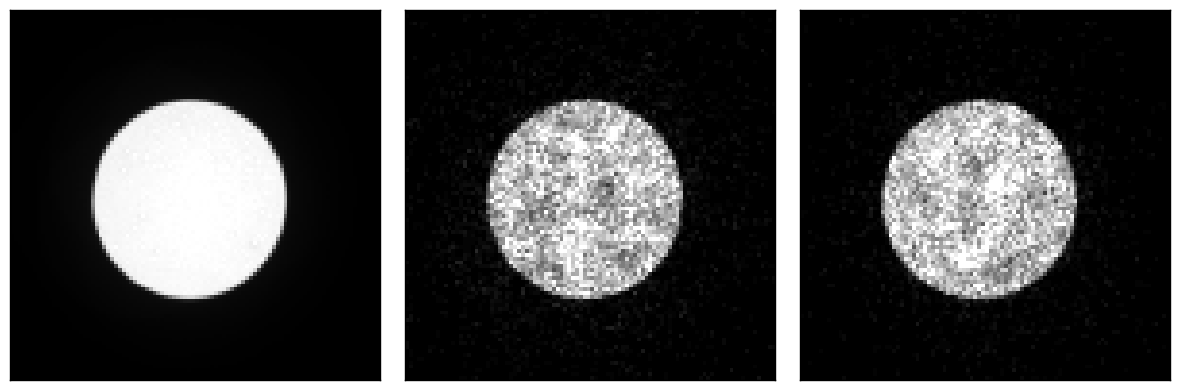

In [8]:
em.visualization.show_2d(
    [
        dc.dp_mean,
        dc.array[30,30],
        dc.array[15,15]
    ]
)

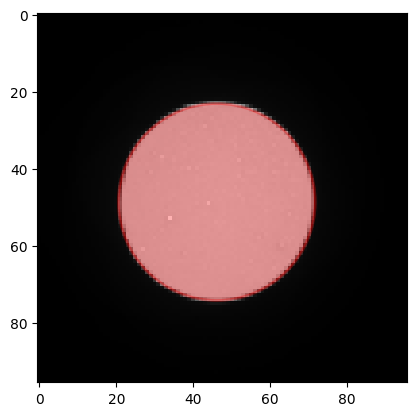

In [9]:
from quantem.core.utils.diffractive_imaging_utils import fit_probe_circle
probe_qy0, probe_qx0, probe_R = fit_probe_circle(dc.dp_mean.array, show=True)
dc.sampling[2] = probe_semiangle / probe_R
dc.sampling[3] = probe_semiangle / probe_R
dc.units[2:] = ["mrad", "mrad"]

## 4. Make Virtual Images

Before moving to ptychography, generate simple virtual detector images:

- a bright-field (BF) image from the central disk
- a dark-field (DF) image from an annular detector

These images are fast to compute and help us check if this is a reasonable field of view for the reconstruction.


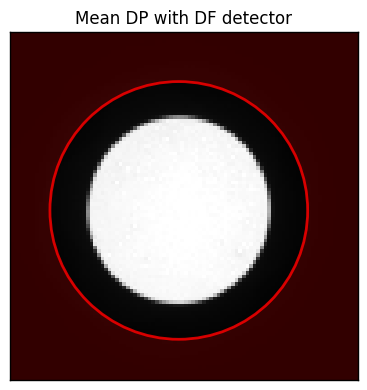

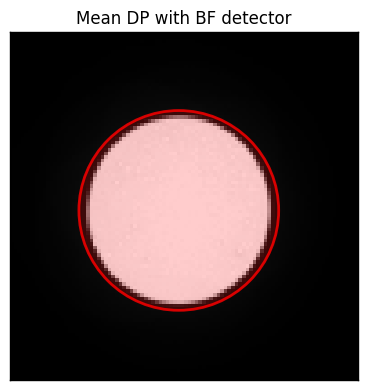

Dataset(shape=(120, 240), dtype=uint64, name='BF')
  sampling: [0.47470101 0.47470101]
  units: ['A', 'A']
  signal units: 'arb. units'

In [10]:
dc.get_virtual_image(
    mode="annular",
    geometry=((probe_qy0, probe_qx0), (probe_R+10, probe_R*5)),
    name="DF",
    show=True,
)

dc.get_virtual_image(
    mode="circle",
    geometry=((probe_qy0, probe_qx0), probe_R+2),
    name="BF",
    show=True,
)



(<Figure size 800x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

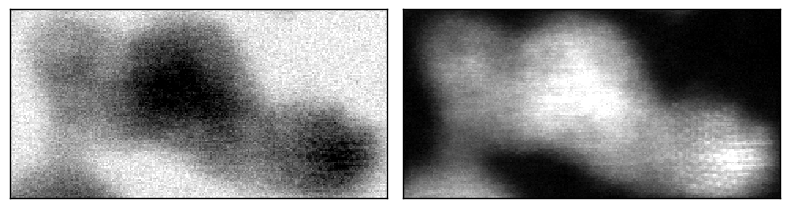

In [11]:
em.visualization.show_2d(
    [
        dc.virtual_images['BF'],
        dc.virtual_images['DF']
    ]

)

Notice these images are very blurry due to the aberrations used to acquire this dataset.

## 5. Direct Ptychography

We begin with `DirectPtychography`, which is fast and useful for getting a reconstruction from the calibrated dataset.

The initialization cell below constructs the direct ptychography object from the 4D-STEM dataset. At this stage we supply:

- the calibrated dataset `dc`
- the beam energy
- the semiangle cutoff
- the compute device

This creates the reconstruction object but does not yet optimize the unknown aberrations or scan rotation. If you already know your rotation angle from previous experiments and calibrations, we highly recommend that you include that when initializing.


In [12]:
direct_ptycho = em.diffractive_imaging.direct_ptychography.DirectPtychography.from_dataset4d(
    dc,
    energy=energy,
    semiangle_cutoff=probe_semiangle,
    device="gpu",
    max_batch_size=32,
    # rotation_angle = -169
)


### 5.1 Coarse Hyperparameter Search

A first direct reconstruction is usually worth doing with a coarse search over the parameters that most often matter first:

- `C10` (defocus)
- `rotation_angle`

Here we use `optimize_hyperparameters(...)` to search over a broad range. The goal is not perfection yet. We just want a plausible first solution that tells us whether the handedness, focus, and overall contrast make sense.


In [13]:
from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter
direct_ptycho.optimize_hyperparameters(
    aberration_coefs={
        "C10":OptimizationParameter(-400,400),
    },
    rotation_angle=OptimizationParameter(-90, 90),
    deconvolution_kernel='parallax',
)



  0%|          | 0/50 [00:00<?, ?it/s]

Optimized state:

 HyperparameterState(
  initial_rotation_angle_deg=14.0,
  optimized_aberrations={'C10': 160.2186598329376},
  optimized_rotation_angle_deg=18.955486942846893,
)


### 5.2 First Direct Reconstruction

After the coarse search, reconstruct once at `upsampling_factor=1`. This gives a quick resut to inspect.

When you look at the output, ask:

- Are the particles sharp or obviously blurred?
- Does the contrast sign make physical sense?
- Are there obvious rotation or astigmatism artifacts?


Reconstructing with:

 HyperparameterState(
  current_aberrations={'C10': 160.2186598329376},
  current_rotation_angle_deg=18.955486942846893,
)


  0%|          | 0/2017 [00:00<?, ?it/s]

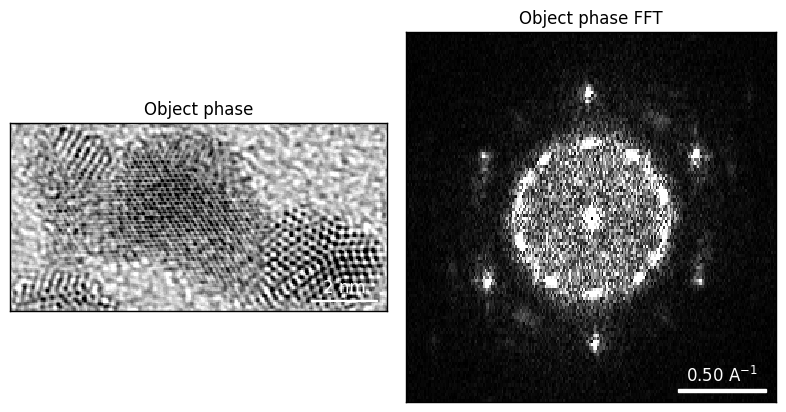

In [14]:
direct_ptycho.reconstruct(
    upsampling_factor = 1,
    deconvolution_kernel='parallax',
    max_batch_size = 32
)
direct_ptycho.visualize()

### 5.3 Refine the Direct Reconstruction

The first result gives us a much better starting point. In this notebook the initial reconstruction has the contrast sign reversed, so we explicitly test a `180` degree rotation offset and refine a narrower set of aberration parameters:

- `C10` for defocus
- `C12` and `phi12` for two-fold astigmatism

This is a common workflow in practice: do a broad search first, inspect the result, then tighten the search window around the physically reasonable region.


  0%|          | 0/50 [00:00<?, ?it/s]

Optimized state:

 HyperparameterState(
  initial_rotation_angle_deg=14.0,
  optimized_aberrations={'C10': -167.35482415094788, 'C12': 2.0101134193068835, 'phi12': 0.9940911137866806},
  optimized_rotation_angle_deg=192.33269159924686,
)
Reconstructing with:

 HyperparameterState(
  current_aberrations={'C10': -167.35482415094788, 'C12': 2.0101134193068835, 'phi12': 0.9940911137866806},
  current_rotation_angle_deg=192.33269159924686,
)


  0%|          | 0/2017 [00:00<?, ?it/s]

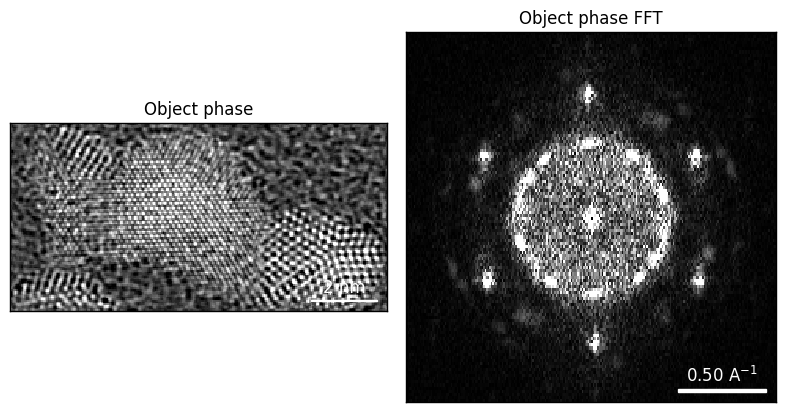

In [15]:
from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter
direct_ptycho.optimize_hyperparameters(
    aberration_coefs={
        "C10":OptimizationParameter(-250,0),
        "C12":OptimizationParameter(0, 40),
        "phi12":OptimizationParameter(-np.pi/2, np.pi/2)
    },
    rotation_angle=OptimizationParameter(
        direct_ptycho.rotation_angle + 180-15,
        direct_ptycho.rotation_angle + 180+15,
    ),
    deconvolution_kernel='parallax',
)

direct_ptycho.reconstruct(
    upsampling_factor = 1,
    deconvolution_kernel='parallax',
    max_batch_size = 32
)
direct_ptycho.visualize()

### 5.4 Increase the Reconstruction Sampling

Once the low-order parameters look reasonable, rerun the direct reconstruction with `upsampling_factor=2` to recover finer detail.

For this example we are using the parallax-style kernel. Other kernel choices are possible. See the `quantEM` tutorials for more information.

Reconstructing with:

 HyperparameterState(
  current_aberrations={'C10': -167.35482415094788, 'C12': 2.0101134193068835, 'phi12': 0.9940911137866806},
  current_rotation_angle_deg=192.33269159924686,
)


  0%|          | 0/2017 [00:00<?, ?it/s]

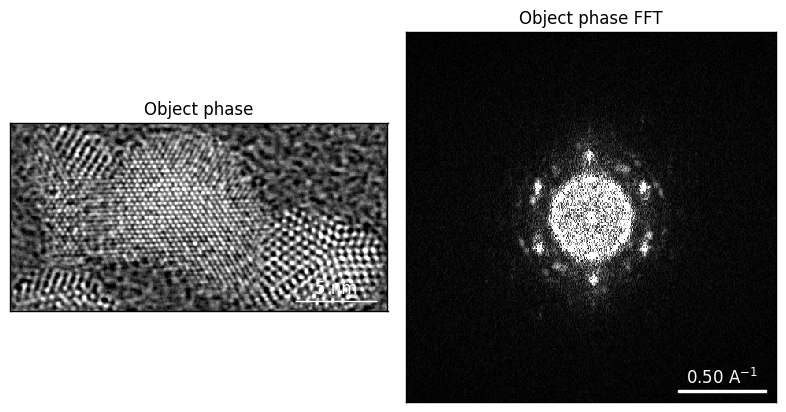

In [16]:
direct_ptycho.reconstruct(
    upsampling_factor = 2,
    deconvolution_kernel='parallax',
    max_batch_size = 32
)
direct_ptycho.visualize()

At this point the direct reconstruction should look substantially better than the first-pass result. In `quantEM`, increasing the upsampling factor can improve detail, but it also increases the computational cost. For this dataset, `upsampling_factor=2` is a practical stopping point. The maximum resolution that can be reached is two times the semiconvergence angle.

For more background on direct ptychographic reconstruction acronyms and how methods such as parallax and single-sideband relate to one another, see Ref. [1].


## 6. Iterative Ptychography with `PtychoLite`

Next we switch to an iterative reconstruction. `PtychoLite` is a higher-level wrapper around the full ptychography machinery in `quantEM`, so it is a convenient place to start if you want a more flexible iterative refinement workflow.

This tutorial keeps the example simple and uses a single-slice object model. In the final reconstruction for publication, multislice often becomes important for thicker specimens, where a single projected transmission function is no longer a good approximation and propagation through the sample thickness needs to be modeled more explicitly.

In [17]:
from quantem.core.datastructures import Dataset4dstem
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.ptychography_lite import PtychoLite, PtychoLiteDIP

### 6.1 Build and Preprocess the Iterative Dataset

First convert the calibrated 4D-STEM dataset into the raster dataset model expected by the iterative ptychography code.

The preprocessing step estimates scan geometry quantities from the center-of-mass (COM) signal. In this notebook we explicitly inspect the COM-based rotation plots and then force the rotation/transpose choice. That is helpful when you already know the physically correct orientation and want a reproducible tutorial workflow.


Forcing best fit rotation to -169 degrees.
Forcing transpose of intensities to False.


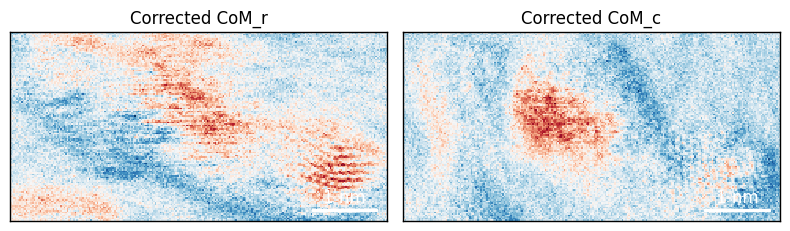

Normalizing intensities:   0%|          | 0/28800 [00:00<?, ?probe position/s]

In [18]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dc)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
    probe_energy=energy,
    force_com_rotation=-169,
    force_com_transpose = False,
)


### 6.2 Initialize `PtychoLite`

Now build the iterative reconstruction object. We carry over the direct ptychography aberration estimate through `polar_parameters=direct_ptycho.aberration_coefs`.

In this tutorial we keep `num_slices=1` and reconstruct a single projected object for clarity. If you are working with a thicker sample, a next step is to switch to a multislice object model by increasing `num_slices` and providing physically meaningful slice thicknesses.

For partially coherent or mixed-state data, you can also reconstruct with multiple probes by increasing the number of probe modes.

Using the direct reconstruction as an informed starting point often makes the iterative reconstruction more stable and reduces the amount of blind parameter search.

In [19]:
ptycho_pix = PtychoLite.from_dataset(
    dset=pdset,
    obj_type="potential",
    energy=energy,
    semiangle_cutoff=probe_semiangle,
    device="cpu",
    polar_parameters = direct_ptycho.aberration_coefs,
)

### 6.3 Run the Iterative Reconstruction

The reconstruction cell below performs `50` iterations and lets both the object and probe update.

Important knobs to notice:

- `num_iters`: total optimization steps
- `batch_size`: how many diffraction patterns are processed at once
- `lr_obj`: learning rate for the object
- `lr_probe`: learning rate for the probe

If the reconstruction looks unstable, the first things to revisit are usually preprocessing, learning rates, and the probe initialization.


  0%|          | 0/24 [00:00<?, ?it/s]

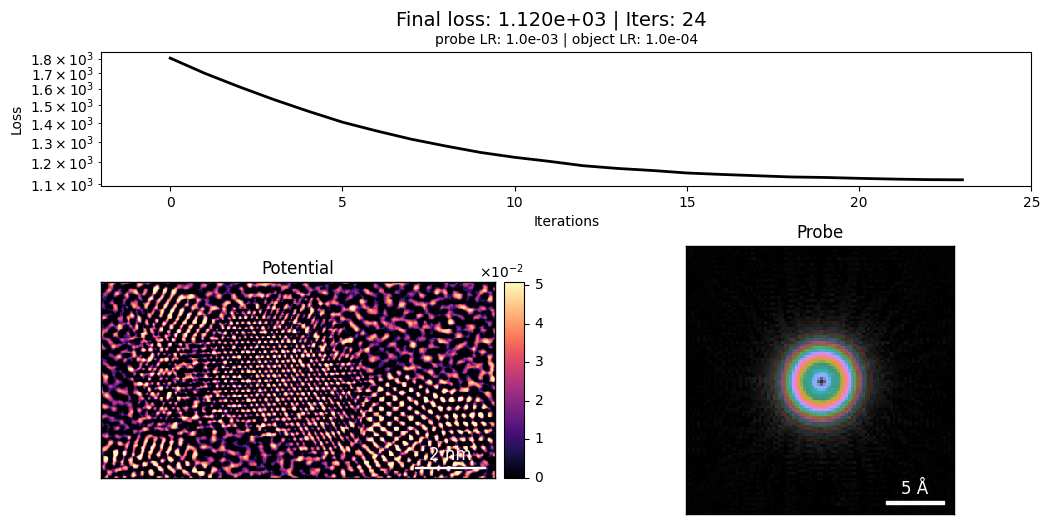

In [20]:
ptycho_pix.reconstruct(
    num_iters=24,
    device="gpu",
    batch_size=1024,
    reset = True,
    lr_obj = 1e-4,
    lr_probe = 1e-3,
).visualize()


## 7. Compare the Results

Finally, compare three views side by side:

1. the dark-field virtual image
2. the direct ptychography reconstruction
3. the iterative ptychography reconstruction


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'DF'}>,
        <Axes: title={'center': 'parallax'}>,
        <Axes: title={'center': 'iterative'}>], dtype=object))

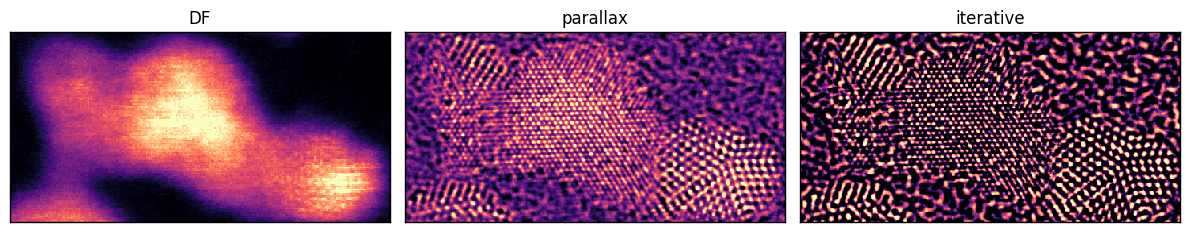

In [21]:
em.visualization.show_2d(
    [
        dc.virtual_images['DF'],
        direct_ptycho.obj,
        ptycho_pix.obj_cropped.sum(0)
    ],
    cmap  = "magma",
    title = ['DF', 'parallax', 'iterative']
)

## 8. What to Notice and What to Try Next

For this dataset, the main practical takeaway is:

- direct ptychography gets to a useful answer quickly
- iterative ptychography has more room for refinement, but it is slower and more sensitive to hyperparameters

This notebook demonstrates a single-slice iterative reconstruction because it is easier to teach and faster to run. Multislice and mixed state are necessary for most experimental datasets.

Iterative methods can, in some cases, recover higher resolution or out of plane 3D-information, but they also converge more slowly, especially in the low spatial frequency content of the object. Ref. [2] points to a deep image prior direction you could try next for faster iterative ptychography convergence with better regularization. Also check out other `quantEM` tutorials to learn about the deep image prior framework.

Follow-up exercises are:

1. change the number of iterations
2. test different learning rates
3. move from single-slice to multislice for thicker specimens
4. compare parallax and SSB-style direct kernels
5. explore additional `quantEM` notebooks after you are comfortable with this baseline workflow


## References

[1] G. Varnavides, W. P. M. de Kleijne, and S. M. Ribet, "The ABCs of phase retrieval: Connecting the acronyms of scanning transmission electron microscopy," *MRS Bulletin* (2026). DOI: <https://doi.org/10.1557/s43577-026-01100-3>. A later correction notice appears at <https://doi.org/10.1557/s43577-026-01149-0>.

[2] A. R. C. McCray, S. M. Ribet, G. Varnavides, and C. Ophus, "Deep generative priors for robust and efficient electron ptychography," *arXiv* (2025). DOI: <https://doi.org/10.48550/arXiv.2511.07795>.